In [13]:
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
file = pd.read_csv("./checkdatas/FE_pima_diabetes.csv")
train = file.copy()
train.head()

AttributeError: 'DataFrame' object has no attribute 'encoding'

In [15]:
train.shape

(768, 9)

In [16]:
y_train = train['Outcome']
X_train = train.drop(['Outcome'],axis=1)

feat_names = train.columns


In [27]:
from scipy.sparse import csr_matrix
X_train = csr_matrix(X_train)
type(X_train)

scipy.sparse._csr.csr_matrix

In [18]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [19]:
from sklearn.model_selection import cross_val_score
# 将训练集 (X_train, y_train) 分成 5 份，通过交叉验证的方式，得到每个样本在未参与训练时被模型预测的概率（或类别），从而避免过拟合的预测偏差。
loss = cross_val_score(lr,X_train,y_train,cv=5,scoring='neg_log_loss')
print('logloss of each fold is:',-loss)
print('cv logloss is:',-(loss.mean()))

logloss of each fold is: [0.48808153 0.53001521 0.45625742 0.42246801 0.48389825]
cv logloss is: 0.47614408619360915


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

penaltys = ['l1','l2']
cs = [0.1,1,10,100,1000]
tuned_parameters = dict(penalty=penaltys,C=cs)
lr_penalty = LogisticRegression(solver='liblinear')

grid = GridSearchCV(lr_penalty, tuned_parameters, cv=5, 
                        scoring='neg_log_loss', n_jobs=1,return_train_score=True)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'), n_jobs=1,
             param_grid={'C': [0.1, 1, 10, 100, 1000], 'penalty': ['l1', 'l2']},
             return_train_score=True, scoring='neg_log_loss')

In [62]:
print("最小log损失：", -grid.best_score_)
print("最佳超参数：", grid.best_params_) 

最小log损失： 0.4759666605898955
最佳超参数： {'C': 1, 'penalty': 'l1'}


In [63]:
lr_penalty_accuracy = LogisticRegression(solver='liblinear')
grid_accuracy = GridSearchCV(lr_penalty_accuracy,tuned_parameters,cv=5,scoring='accuracy',n_jobs=1)
grid_accuracy.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'), n_jobs=1,
             param_grid={'C': [0.1, 1, 10, 100, 1000], 'penalty': ['l1', 'l2']},
             scoring='accuracy')

In [64]:
print("最佳准确率：", grid_accuracy.best_score_)
print("最佳超参数：", grid_accuracy.best_params_) 

最佳准确率： 0.7747644512350395
最佳超参数： {'C': 0.1, 'penalty': 'l2'}


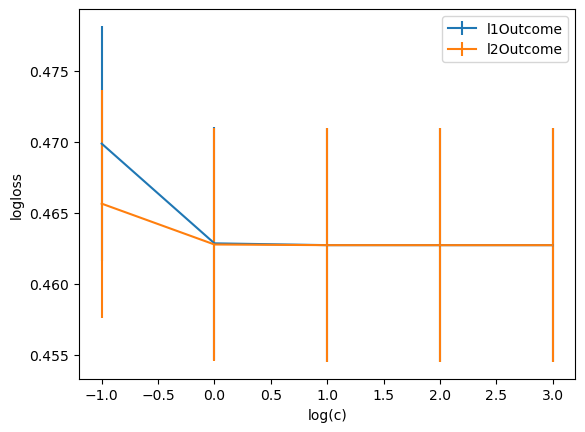

In [68]:
train_means = grid.cv_results_['mean_train_score']
train_stds = grid.cv_results_['std_train_score']

n_cs = len(cs)
number_penaltys = len(penaltys)

train_score = np.array(train_means).reshape(n_cs,number_penaltys)
train_stds = np.array(train_stds).reshape(n_cs,number_penaltys)

x_axis = np.log10(cs)
for i,value in enumerate(penaltys):
    plt.errorbar(x_axis,-train_score[:,i],yerr=train_stds[:,i],label=penaltys[i]+'Outcome')

plt.legend()
plt.xlabel('log(c)')
plt.ylabel('logloss')
plt.savefig('LogisticGridSearchCV_c.png')

plt.show()

In [69]:
import pickle as cPickle

cPickle.dump(grid.best_estimator_, open("logloss_l1.pkl", 'wb'))
cPickle.dump(grid_accuracy.best_estimator_, open("accuracy_l2.pkl", 'wb'))